## **0. Giới thiệu**
Trong lĩnh vực chăm sóc sức khỏe, việc phát hiện và phòng ngừa sớm đóng vai trò then chốt trong việc kiểm soát các tình trạng mãn tính và cải thiện kết quả của bệnh nhân. **Đái tháo đường** hay **tiểu đường** là một nhóm các rối loạn chuyển hóa đặc trưng là tình trạng đường huyết cao kéo dài, đây là một bệnh phổ biến gây những rủi ro đáng kể nếu không được điều trị kịp thời. Trong bối cảnh khoa học phát triển, việc tích hợp các kỹ thuật học máy hứa hẹn sẽ cách mạng hóa các hoạt động chăm sóc sức khỏe, đặc biệt là trong phân tích và dự đoán.

<div style="display: flex; justify-content: center">
    <img 
        src="https://media.licdn.com/dms/image/v2/D4E12AQFzvBcN0L5pGg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1700613031139?e=2147483647&v=beta&t=9IxUSLYBHu4idDvlS6F_HqYX5Z1iIOXgbL9iH1C_dc0"
        alt="Application Machine Learning in diabetes prediction"
        style="width: 800px;"
    />
</div>

Trong dự án lần này, chúng ta sẽ tập trung vào việc phân tích các yếu tố nguy cơ và xây dựng một hệ thống dự đoán khả năng mắc bệnh tiểu đường dựa trên bộ dữ liệu từ **Behavioral Risk Factor Surveillance System (BRFSS)** năm 2021 của CDC cung cấp.

Trong dự án này, chúng ta sẽ sử dụng bộ dữ liệu `diabetes_012_health_indicators_BRFSS2021`, vì đây là một bộ dữ liệu có nhiều record để giúp mô hình học tốt hơn, ngoài ra bộ dữ liệu này có các class chi tiết hơn so với 2 bộ lại. Bộ dữ liệu này đặc biệt thú vị vì nó không chỉ phân loại người bệnh thành hai nhóm (có/không có tiểu đường) mà còn bao gồm cả giai đoạn tiền tiểu đường (Có khả năng bị tiểu đường). Điều này cho phép chúng ta có cái nhìn chi tiết hơn về quá trình phát triển của bệnh và các yếu tố ảnh hưởng.

## **1. Thư viện**

Trong phần này, chúng ta sẽ thêm những thư viện yêu cầu cần thiết cho dự án Diabetes Prediction của chúng ta. Chúng ta có 2 thư viện là **Numpy** và **Pandas**, đây là 2 thư viện chuyên dụng cho quá trình thao tác với dữ liệu. Thư viện **Matplotlib** và **Seaborn** là hai thư viện phổ biến trong việc trực quan hóa dữ liệu và thự hiện các Exploration Data Analysic (EDA). Ngoài ra, chúng ta còn sử dụng một số thư viện của Python như **os**, **warnings**. Updating...

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings

plt.style.use('seaborn-v0_8-whitegrid')

## **2. Dataset**

Trong dự án này, chúng ta sẽ sử dụng bộ dữ liệu `diabetes_012_health_indicators_BRFSS2021`, vì đây là một bộ dữ liệu có đầy đủ các record để giúp mô hình học tốt hơn, ngoài ra bộ dữ liệu này có các class chi tiết hơn so với 2 bộ lại. Bộ dữ liệu này đặc biệt thú vị vì nó không chỉ phân loại người bệnh thành hai nhóm (có/không có tiểu đường) mà còn bao gồm cả giai đoạn tiền tiểu đường (Có khả năng bị tiểu đường). Điều này cho phép chúng ta có cái nhìn chi tiết hơn về quá trình phát triển của bệnh và các yếu tố ảnh hưởng.

- **Tên tệp**: `diabetes_012_health_indicators_BRFSS2021.csv`
- **Số lượng mẫu**: 236,378
- **Số lượng cột**: 22
- **Mục tiêu**: Cột `Diabetes_012` (0: Không bị tiểu đường, 1: Tiền tiểu đường, 2: Tiểu đường).
- **Các cột đặc trưng**: Bao gồm chỉ số BMI, huyết áp cao, cholesterol, hoạt động thể chất, và các yếu tố nhân khẩu học như tuổi, giới tính, thu nhập, v.v.

Bảng mô tả ý nghĩa các cột:

| Tên cột | Mô tả |
|---------|--------|
| Diabetes_012 | Tình trạng tiểu đường (0: không, 1: tiền tiểu đường, 2: tiểu đường) |
| HighBP | Huyết áp cao (0: không, 1: có) |
| HighChol | Cholesterol cao (0: không, 1: có) |
| CholCheck | Kiểm tra Cholesterol trong 5 năm qua (0: không, 1: có) |
| BMI | Chỉ số khối cơ thể |
| Smoker | Đã từng hút thuốc ít nhất 100 điếu trong đời (0: không, 1: có) |
| Stroke | Đã từng bị đột quỵ (0: không, 1: có) |
| HeartDiseaseorAttack | Đã từng mắc bệnh tim hoặc đau tim (0: không, 1: có) |
| PhysActivity | Hoạt động thể chất trong 30 ngày qua (0: không, 1: có) |
| Fruits | Ăn trái cây ít nhất 1 lần/ngày (0: không, 1: có) |
| Veggies | Ăn rau ít nhất 1 lần/ngày (0: không, 1: có) |
| HvyAlcoholConsump | Uống rượu bia nặng (nam >14 ly/tuần, nữ >7 ly/tuần) (0: không, 1: có) |
| AnyHealthcare | Có bất kỳ bảo hiểm y tế nào (0: không, 1: có) |
| NoDocbcCost | Không đi khám bác sĩ vì chi phí trong 12 tháng qua (0: không, 1: có) |
| GenHlth | Đánh giá sức khỏe tổng quát (1-5: xuất sắc đến kém) |
| MentHlth | Số ngày sức khỏe tâm thần không tốt trong 30 ngày qua (0-30) |
| PhysHlth | Số ngày sức khỏe thể chất không tốt trong 30 ngày qua (0-30) |
| DiffWalk | Khó khăn khi đi bộ hoặc leo cầu thang (0: không, 1: có) |
| Sex | Giới tính (0: nữ, 1: nam) |
| Age | Nhóm tuổi (1: 18-24, 2: 25-29, ..., 13: 80+ tuổi) |
| Education | Trình độ học vấn (1: chưa tốt nghiệp cấp 3, 2: tốt nghiệp cấp 3, 3: học một số đại học, 4: tốt nghiệp đại học) |
| Income | Thu nhập hàng năm (1: dưới $10,000, 2: $10,000-$15,000, ..., 8: $75,000+) |

Để tăng tính linh động trong việc dữ liệu, chúng ta sẽ load dữ liệu từ github

In [7]:
def load_dataset_from_github():
    '''
        Hàm tải và đọc file diabetes_012_health_indecator_BRFSS2021.csv
        Return: 
            pandas.DataFrame: DateFrame chứa dữ liệu diabetes_012_health_indicators_BRFSS2021
    '''
    # Tạo thư mục data nếu chưa tốn tại
    if not os.path.exists('data'):
        print('Đang khởi tạo thư mục chứ dữ liệu...')
        os.mkdir('data')
    
    # Đường dẫn đến file csv trong thư mục data
    csv_path = './data/diabetes_012_health_indicators_BRFSS2021.csv'

    # Kiểm tra nếu file đã tồn tại
    if os.path.exists(csv_path):
        print('File đã tồn tại trong thư mục data, đang đọc file...')
        return pd.read_csv(csv_path)
    
    # Fetch dữ liệu từ github
    try:
        print('Dữ liệu chưa tồn tại trong thư mục data, đang kết nối và tải dữ liệu từ github...')
        # URL của file csv
        raw_url = 'https://raw.githubusercontent.com/lngquoctrung/diabetes-prediction-machine-learning/refs/heads/main/data/original/diabetes_012_health_indicators_BRFSS2021.csv'
        # Tải file
        dataframe = pd.read_csv(raw_url)
        print('Tải dữ liệu thành công, đang lưu dữ liệu xuống local...')
        dataframe.to_csv(csv_path, index=False)
        print('Lưu dữ liệu thành công.')
        return dataframe
    # Lỗi kết nối đến đường dẫn
    except Exception as e:
        print(f'Đã có lỗi xảy ra: {str(e)}')
        return None


In [8]:
# Gọi hàm để tải và load dữ liệu
df = load_dataset_from_github()

Đang khởi tạo thư mục chứ dữ liệu...
Dữ liệu chưa tồn tại trong thư mục data, đang kết nối và tải dữ liệu từ github...
Tải dữ liệu thành công, đang lưu dữ liệu xuống local...
Lưu dữ liệu thành công.


In [9]:
# Số dòng và số cột của bộ dữ liệu
df.shape

(236378, 22)

In [11]:
# 5 dòng đầu của bộ dữ liệu
df.head(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,2.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,2.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,2.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0


In [12]:
# 5 dòng cuối của bộ dữ liệu
df.tail(5)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
236373,2.0,1,1.0,1,21.0,0.0,0.0,0.0,1,1,...,1,0.0,4.0,0.0,0.0,0.0,1,10,2.0,3.0
236374,0.0,1,0.0,1,25.0,1.0,0.0,0.0,1,1,...,0,1.0,2.0,20.0,0.0,0.0,0,3,4.0,5.0
236375,0.0,0,1.0,1,31.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,0.0,0.0,0.0,1,7,6.0,10.0
236376,0.0,1,0.0,1,24.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,0.0,0.0,0.0,1,10,4.0,6.0
236377,0.0,0,1.0,1,32.0,0.0,0.0,0.0,1,0,...,1,0.0,1.0,2.0,2.0,0.0,0,6,6.0,6.0


In [13]:
# Tổng quan về bộ dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               236378 non-null  float64
 15  

## **3. Trực quan hóa dữ liệu**

In [14]:
# Các cột của bộ dữ liệu
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [32]:
# Thống kê tổng quan
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,236378.0,0.307791,0.705037,0.0,0.0,0.0,0.0,2.0
HighBP,236378.0,0.418558,0.493324,0.0,0.0,0.0,1.0,1.0
HighChol,236378.0,0.402059,0.490315,0.0,0.0,0.0,1.0,1.0
CholCheck,236378.0,0.963347,0.187909,0.0,1.0,1.0,1.0,1.0
BMI,236378.0,28.953579,6.552055,12.0,24.0,28.0,32.0,99.0
Smoker,236378.0,0.411997,0.492196,0.0,0.0,0.0,1.0,1.0
Stroke,236378.0,0.038900,0.193356,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,236378.0,0.086548,0.281172,0.0,0.0,0.0,0.0,1.0
PhysActivity,236378.0,0.779231,0.414766,0.0,1.0,1.0,1.0,1.0
Fruits,236378.0,0.621259,0.485074,0.0,0.0,1.0,1.0,1.0


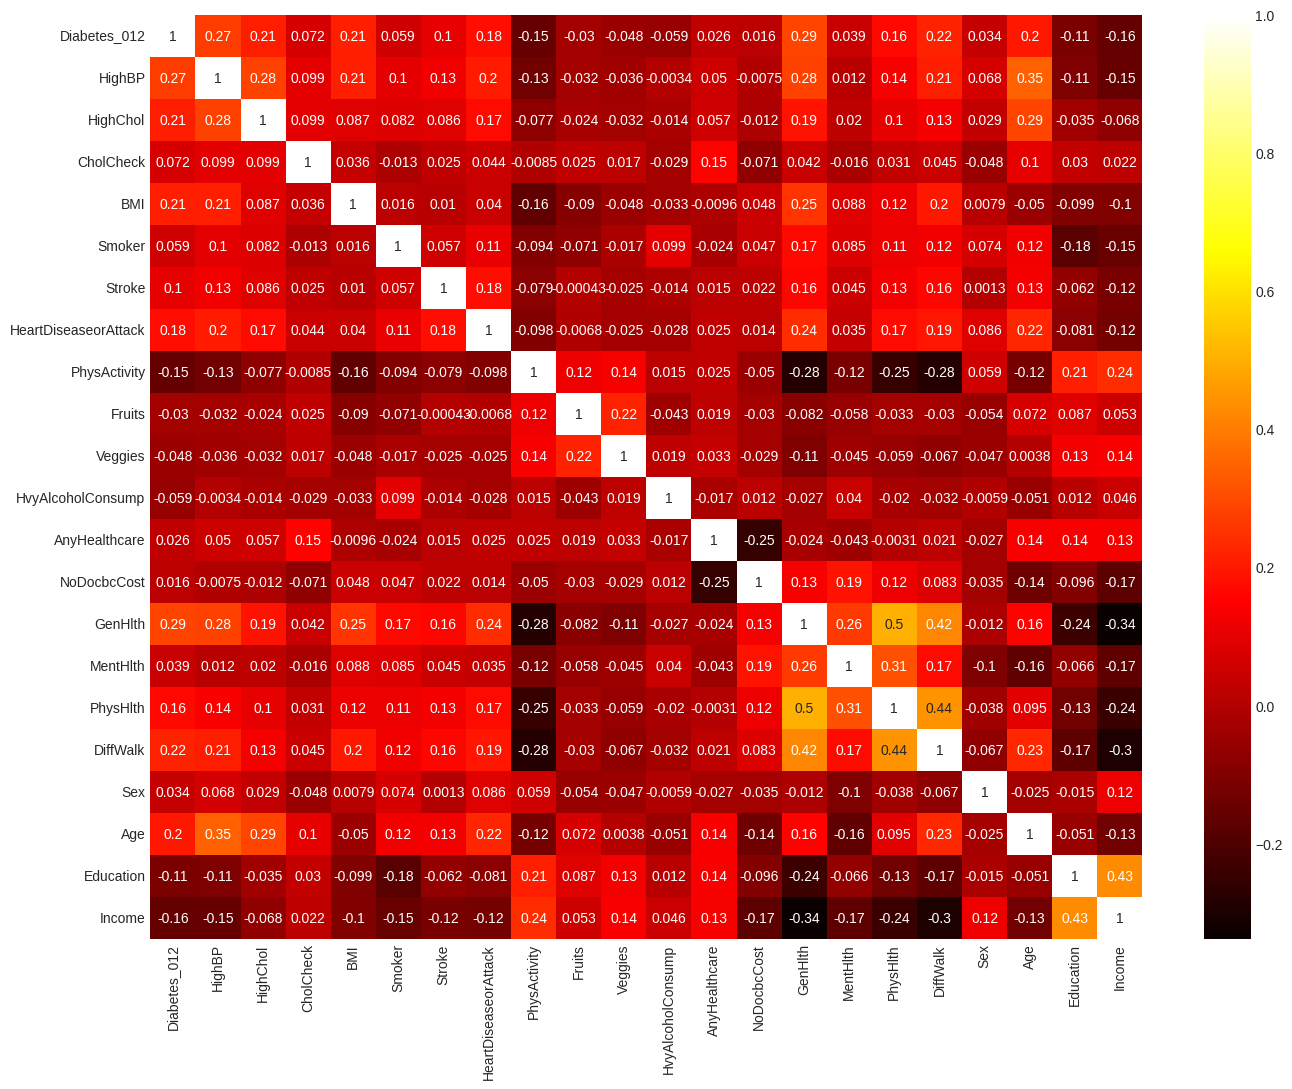

In [30]:
# Biểu đồ nhiệt thể hiện độ tương quan giữa các feature
plt.figure(figsize=(16, 12))
ax = sns.heatmap(df.corr(), cmap='hot', annot=True)
plt.show()